<a href="https://colab.research.google.com/github/riyu658/olist-ecommerce-analytics/blob/main/03_exploratory_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')

In [ ]:
# Loading the master dataset from notebook-2

master = pd.read_csv('/content/drive/My Drive/olist/olist_master.csv', parse_dates=[
    'order_purchase_timestamp', 'order_delivered_customer_date',
    'order_estimated_delivery_date'])

In [ ]:
# Only delivered orders with valid delivery data

df = master[(master['order_status'] == 'delivered') &
            (master['delivery_days'].notna()) &
            (master['delivery_days'] >= 0) &
            (master['delivery_days'] <= 60)].copy()   # dropping the 209-day outlier

print(f"Analysis frame: {len(df):,} orders (from {len(master):,})")

Analysis frame: 96,182 orders (from 99,441)


In [ ]:
# 📊 KPI Snapshot

print("="*45)
print("           KPI SNAPSHOT")
print("="*45)
print(f"Total Orders (delivered): {len(df):,}")
print(f"Total Revenue:            R$ {df['total_price'].sum():,.0f}")
print(f"Average Order Value:      R$ {df['total_price'].mean():,.2f}")
print(f"Avg Delivery Time:        {df['delivery_days'].mean():.1f} days")
print(f"On-Time Rate:             {(~df['was_late']).mean()*100:.1f}%  "
      f"(late: {df['was_late'].mean()*100:.1f}%)")

# Repeat customers = unique customers with >1 order
orders_per_cust = df.groupby('customer_unique_id')['order_id'].nunique()
repeat_rate = (orders_per_cust > 1).mean() * 100
print(f"Repeat Customer Rate:     {repeat_rate:.1f}%  "
      f"({(orders_per_cust > 1).sum():,} of {orders_per_cust.nunique():,} customers)")

           KPI SNAPSHOT
Total Orders (delivered): 96,182
Total Revenue:            R$ 13,167,086
Average Order Value:      R$ 136.90
Avg Delivery Time:        11.9 days
On-Time Rate:             93.5%  (late: 6.5%)
Repeat Customer Rate:     3.0%  (2,793 of 9 customers)


##**1. Order Trends Over Time**

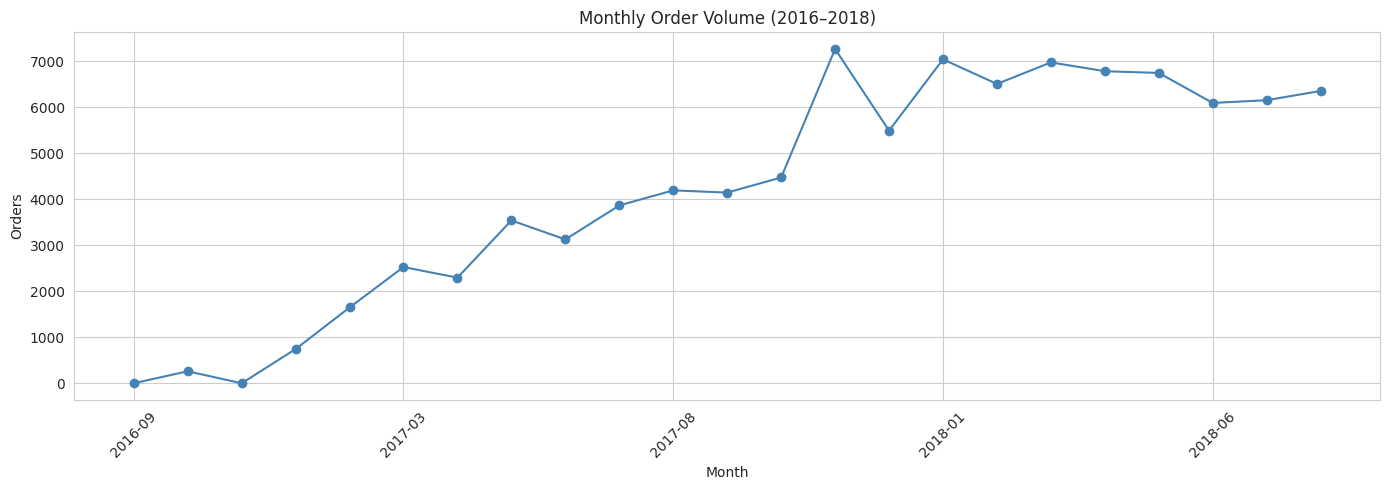

In [ ]:
# Monthly Orders

monthly = df.groupby('purchase_month').size()

fig, ax = plt.subplots(figsize=(14, 5))
monthly.plot(ax=ax, marker='o', color='steelblue')
ax.set_title('Monthly Order Volume (2016–2018)')
ax.set_xlabel('Month'); ax.set_ylabel('Orders')
plt.xticks(rotation=45)
plt.tight_layout(); plt.show()

##**2. Delivery Performance vs Review Scores**

In [ ]:
# Hypothesis: Late deliveries = Lower review scores

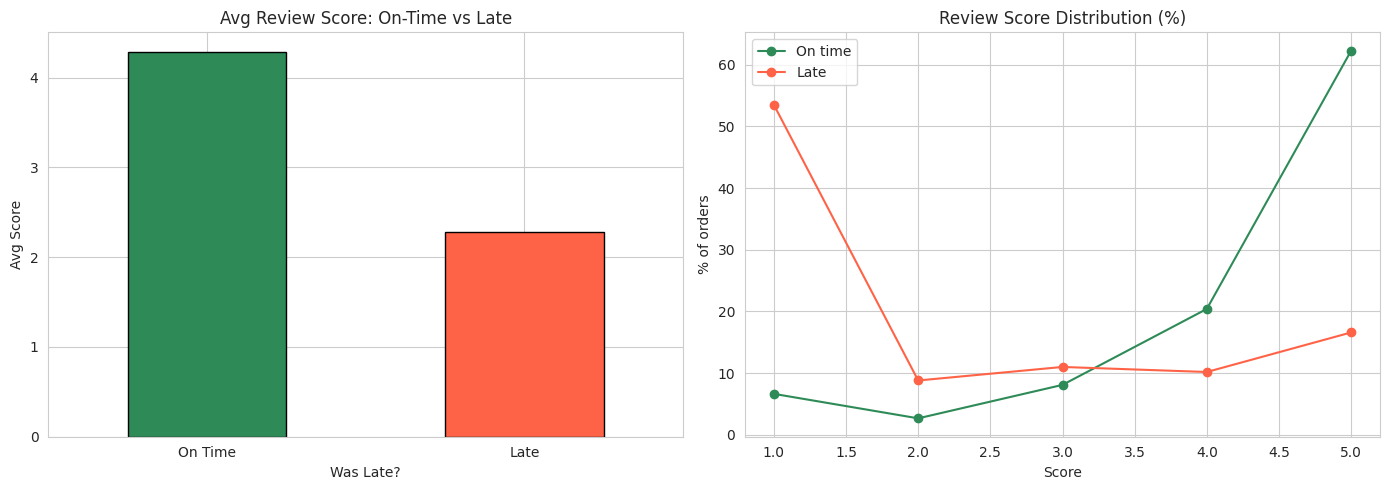

Avg score on-time: 4.29
Avg score late:    2.28
1-star rate on-time: 6.6%
1-star rate late:    52.3%


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Review score: late vs on-time
df.groupby('was_late')['review_score'].mean().plot.bar(
    ax=axes[0], color=['seagreen', 'tomato'], edgecolor='black')
axes[0].set_title('Avg Review Score: On-Time vs Late')
axes[0].set_xlabel('Was Late?'); axes[0].set_ylabel('Avg Score')
axes[0].set_xticklabels(['On Time', 'Late'], rotation=0)

# Full distribution
for late, color, label in [(False, 'seagreen', 'On time'), (True, 'tomato', 'Late')]:
    sub = df[df['was_late'] == late]['review_score'].value_counts(normalize=True).sort_index()
    axes[1].plot(sub.index, sub.values * 100, marker='o', color=color, label=label)
axes[1].set_title('Review Score Distribution (%)')
axes[1].set_xlabel('Score'); axes[1].set_ylabel('% of orders'); axes[1].legend()

plt.tight_layout(); plt.show()

print("Avg score on-time:", round(df.loc[~df['was_late'], 'review_score'].mean(), 2))
print("Avg score late:   ", round(df.loc[df['was_late'], 'review_score'].mean(), 2))
print("1-star rate on-time:", f"{(df.loc[~df['was_late'],'review_score']==1).mean()*100:.1f}%")
print("1-star rate late:   ", f"{(df.loc[df['was_late'],'review_score']==1).mean()*100:.1f}%")

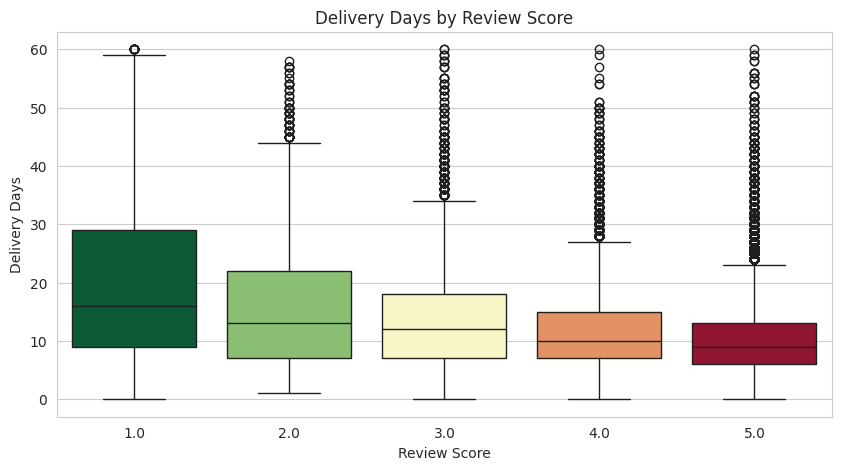

In [ ]:
# Delivery Days vs Score (continuous)

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='review_score', y='delivery_days', palette='RdYlGn_r', hue='review_score', legend=False)
plt.title('Delivery Days by Review Score')
plt.xlabel('Review Score'); plt.ylabel('Delivery Days')
plt.show()

##**3. Review Scores Deep Dive**

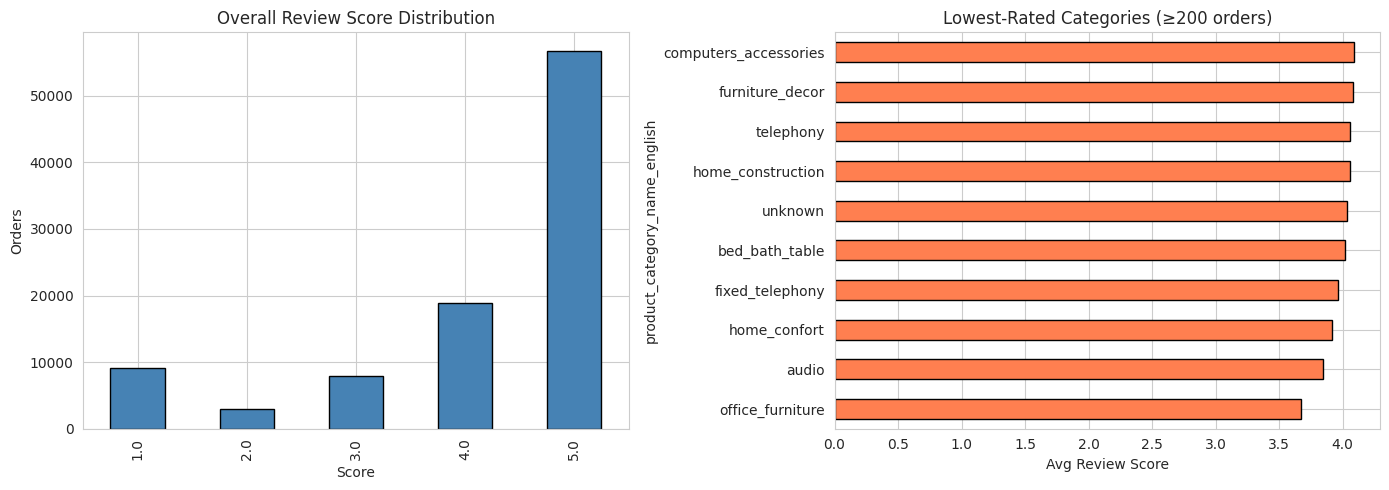

In [ ]:
# Score Distribution by Category

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['review_score'].value_counts().sort_index().plot.bar(
    ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Overall Review Score Distribution')
axes[0].set_xlabel('Score'); axes[0].set_ylabel('Orders')

# Worst categories (min 200 orders)
cat_scores = (df.groupby('product_category_name_english')['review_score']
              .agg(['mean', 'count']))
cat_scores = cat_scores[cat_scores['count'] >= 200].sort_values('mean').head(10)
cat_scores['mean'].plot.barh(ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Lowest-Rated Categories (≥200 orders)')
axes[1].set_xlabel('Avg Review Score')

plt.tight_layout(); plt.show()

##**4. Top Product Categories**

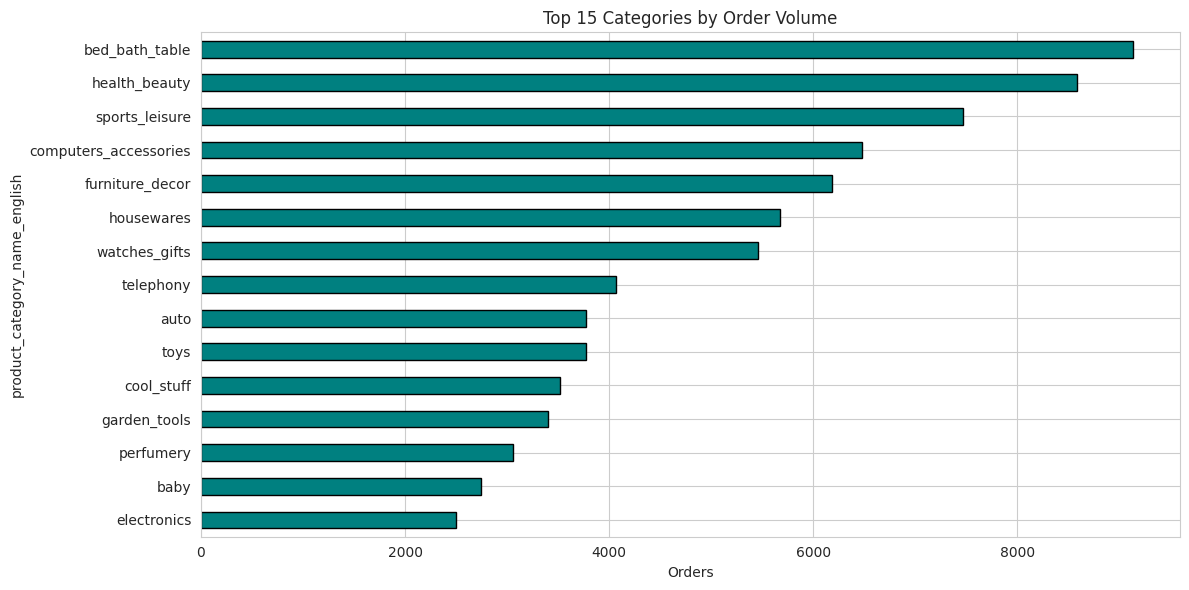

,orders,revenue,avg_price
product_category_name_english,,,
bed_bath_table,9138,1018874.64,111.498647
health_beauty,8586,1227246.37,142.935752
sports_leisure,7471,953264.02,127.595238
computers_accessories,6482,884385.07,136.437067
furniture_decor,6186,711050.06,114.945047
housewares,5677,616615.28,108.616396
watches_gifts,5462,1160667.35,212.498599
telephony,4067,308415.32,75.833617
auto,3770,571938.72,151.707883


In [ ]:
# Category Performance

cat = df.groupby('product_category_name_english').agg(
    orders=('order_id', 'count'),
    revenue=('total_price', 'sum'),
    avg_price=('total_price', 'mean')
).sort_values('orders', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 6))
cat['orders'].sort_values().plot.barh(ax=ax, color='teal', edgecolor='black')
ax.set_title('Top 15 Categories by Order Volume')
ax.set_xlabel('Orders')
plt.tight_layout(); plt.show()

cat

##**5. State-Wise Sales**

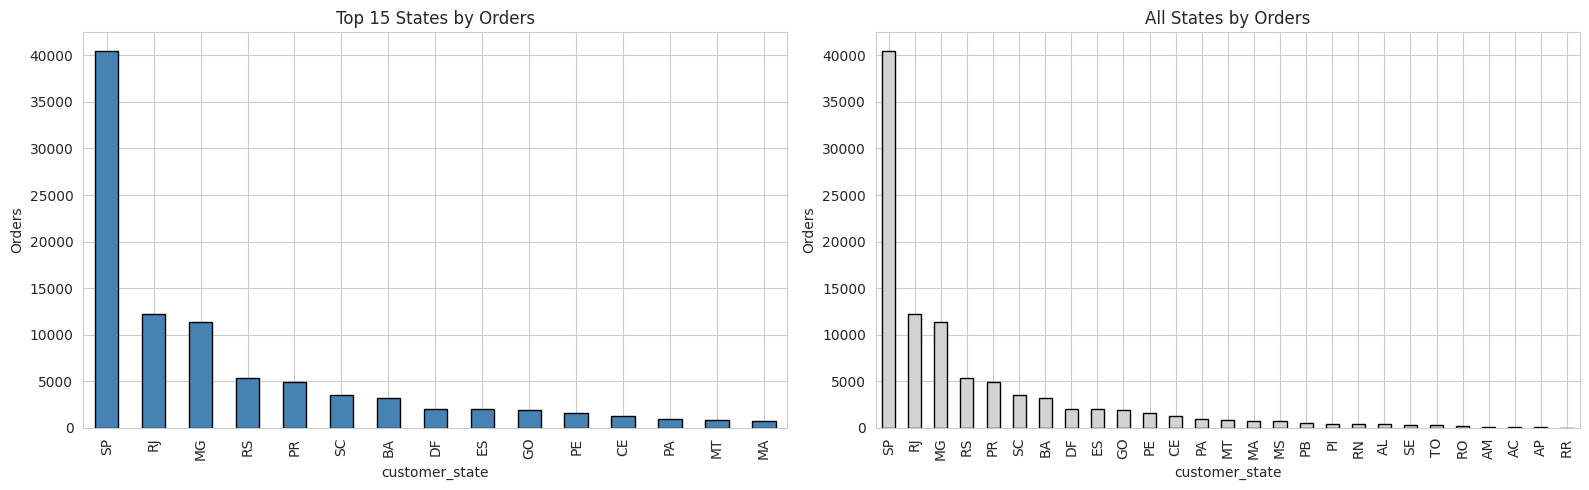

Top state: SP (40,441 orders, 42% of total)


In [ ]:
state = df.groupby('customer_state').agg(
    orders=('order_id', 'count'),
    revenue=('total_price', 'sum')
).sort_values('orders', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
state['orders'].head(15).plot.bar(ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Top 15 States by Orders')
axes[0].set_ylabel('Orders')

state['orders'].sort_values(ascending=False).plot.bar(ax=axes[1], color='lightgray', edgecolor='black')
axes[1].set_title('All States by Orders')
axes[1].set_ylabel('Orders')

plt.tight_layout(); plt.show()
print("Top state:", state.index[0], f"({state['orders'].iloc[0]:,} orders, {state['orders'].iloc[0]/len(df)*100:.0f}% of total)")

##**6. Payment Behavior**

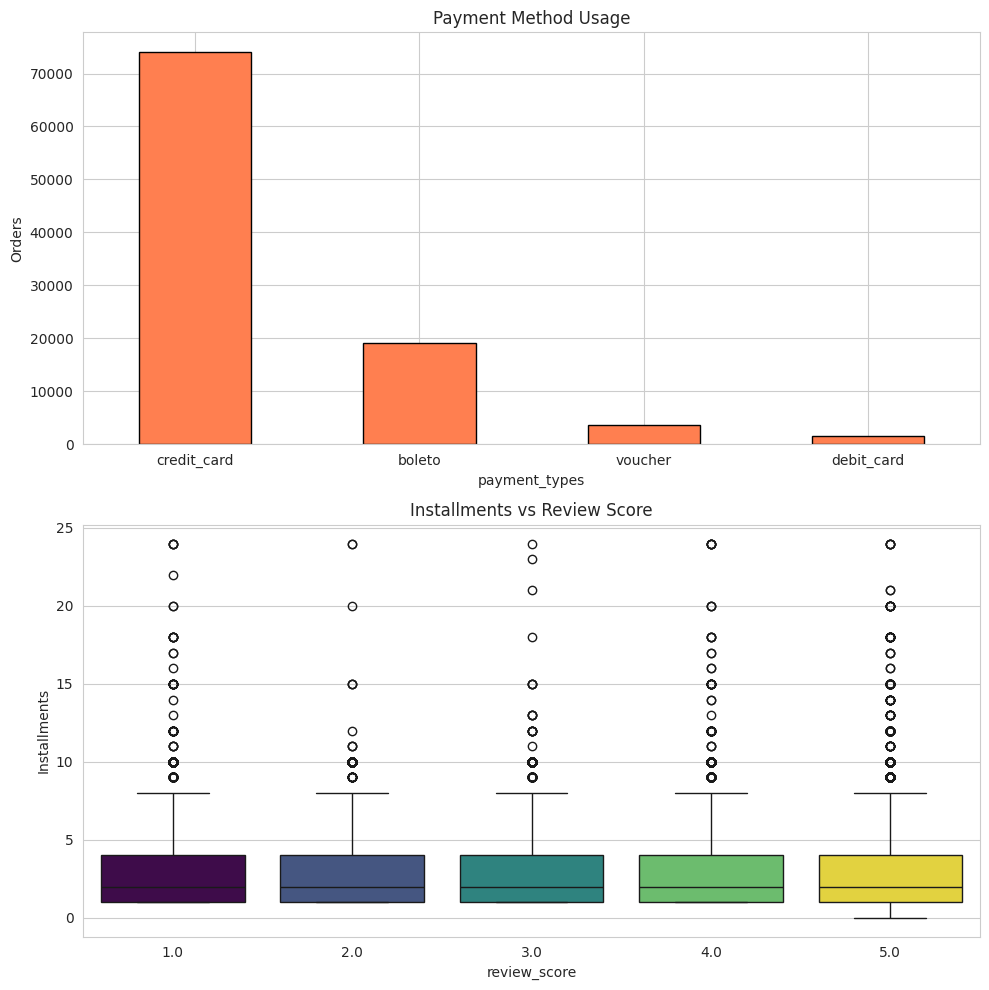

Avg payment value: R$ 159.69
Avg installments:  2.9


In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(10, 10))

df['payment_types'].str.split(', ').explode().value_counts().plot.bar(
    ax=axes[0], color='coral', edgecolor='black')
axes[0].set_title('Payment Method Usage')
axes[0].set_ylabel('Orders'); axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

sns.boxplot(data=df, x='review_score', y='payment_installments', ax=axes[1], palette='viridis', hue='review_score', legend=False)
axes[1].set_title('Installments vs Review Score')
axes[1].set_ylabel('Installments')

plt.tight_layout(); plt.show()

print("Avg payment value:", f"R$ {df['payment_total'].mean():,.2f}")
print("Avg installments: ", round(df['payment_installments'].mean(), 1))

##**7. Price & Frieght Analysis**

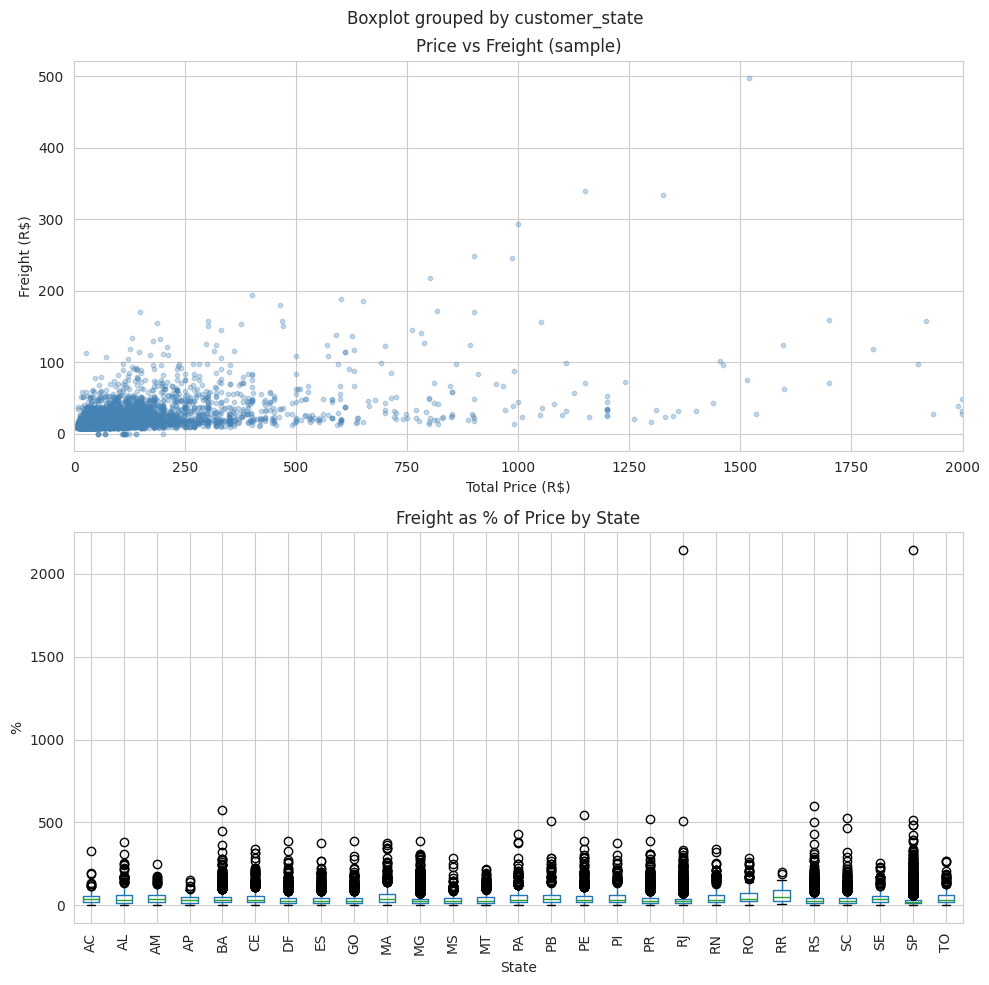

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(10, 10))

sample = df.sample(5000, random_state=42)  # sample for scatter speed
axes[0].scatter(sample['total_price'], sample['total_freight'],
                alpha=0.3, s=10, color='steelblue')
axes[0].set_title('Price vs Freight (sample)')
axes[0].set_xlabel('Total Price (R$)'); axes[0].set_ylabel('Freight (R$)')
axes[0].set_xlim(0, 2000)

df['freight_pct'] = df['total_freight'] / df['total_price'] * 100
df.boxplot(column='freight_pct', by='customer_state', ax=axes[1], rot=90)
axes[1].set_title('Freight as % of Price by State')
axes[1].set_xlabel('State'); axes[1].set_ylabel('%')

plt.tight_layout(); plt.show()

##**Findings:**

1. **Delivery vs Reviews:** Late deliveries average **2.28** vs **4.29** on-time.
   Over half of late orders (52.3%) receive a 1-star review, vs only 6.6% of on-time orders.
   → **Delivery speed is the single biggest driver of customer satisfaction.**

2. **Review skew:** Scores skew polarized — 1★ and 5★ dominate. Customers either love it or hate it; few middle ratings.

3. **Worst categories:** computer_accessories, furniture_decor, telephony → likely shipping-sensitive or quality issues.

4. **Top categories:** bed_bath_table & health_beauty dominate order volume.

5. **Geography:** São Paulo (SP) accounts for [~42%] of orders — extreme regional concentration.

6. **Payments:** Credit card dominates; avg installments = 2.9.

7. **Freight:** Freight is flat (R$20–80) regardless of price — cheap items
   and remote states (RR, AP, AM) carry the heaviest relative burden.
   High freight barely dents reviews (4.21→4.04): **speed matters more than cost.**

In [ ]:
df['freight_pct'] = df['total_freight'] / df['total_price'] * 100
df['freight_bucket'] = pd.cut(df['freight_pct'], bins=[0, 10, 25, 50, 100, np.inf],
                              labels=['<10%', '10-25%', '25-50%', '50-100%', '>100%'])
print(df.groupby('freight_bucket', observed=True)['review_score'].agg(['mean', 'count']))

                    mean  count
freight_bucket                 
<10%            4.206784  14769
10-25%          4.175966  37797
25-50%          4.143512  27503
50-100%         4.126167  12103
>100%           4.041393   3044
